In [ ]:
import numpy as np
from sens_elastic import Cantilever as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 弾性場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta = 0.5 # しきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
fil = Projection(sens.n1, sens.n2, r, eta, beta0) # ヘビサイドプロジェクション
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x) # 密度フィルタ・ヘビサイドプロジェクション後の設計変数
    m_nd = fil.grayscale_indicator(x_proj) # グレースケール指標
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.70e+03, g = -1.36e-02, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 1.18e+03, g = -3.55e-03, norm_inf_x = 5.0e-02, m_nd = 82.70
2 iters, f = 9.53e+02, g = -2.75e-03, norm_inf_x = 5.0e-02, m_nd = 81.66
3 iters, f = 7.98e+02, g = -2.09e-03, norm_inf_x = 5.0e-02, m_nd = 80.08
4 iters, f = 6.80e+02, g = -1.84e-03, norm_inf_x = 5.0e-02, m_nd = 77.96
5 iters, f = 5.84e+02, g = -1.65e-03, norm_inf_x = 5.0e-02, m_nd = 75.20
6 iters, f = 5.05e+02, g = -1.49e-03, norm_inf_x = 5.0e-02, m_nd = 72.05
7 iters, f = 4.51e+02, g = -1.30e-03, norm_inf_x = 5.0e-02, m_nd = 69.35
8 iters, f = 4.05e+02, g = -1.14e-03, norm_inf_x = 5.0e-02, m_nd = 66.76
9 iters, f = 3.66e+02, g = -1.07e-03, norm_inf_x = 5.0e-02, m_nd = 64.17
10 iters, f = 3.31e+02, g = -1.00e-03, norm_inf_x = 5.0e-02, m_nd = 61.33
11 iters, f = 2.99e+02, g = -9.77e-04, norm_inf_x = 5.0e-02, m_nd = 58.55
12 iters, f = 2.71e+02, g = -9.75e-04, norm_inf_x = 5.0e-02, m_nd = 55.39
13 iters, f = 2.45e+02, g = -9.58e-04, norm_inf_

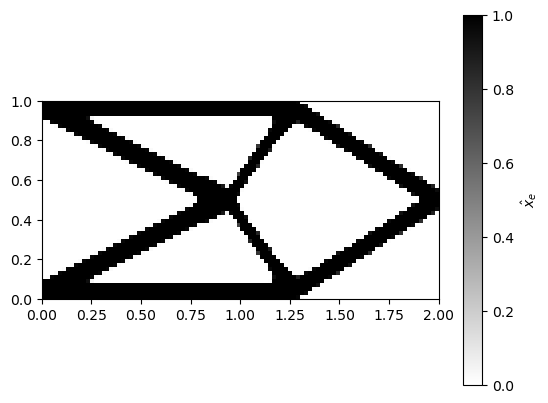

In [15]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_proj.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_e$')

In [5]:
def plot_deformation(sens, x_proj, d, scale=1.0):
    X = np.linspace(0, sens.L1, sens.nnx)
    Y = np.linspace(0, sens.L2, sens.nny)
    X, Y = np.meshgrid(X, Y)
    ux = d[0::2].reshape(sens.nny, sens.nnx)
    uy = d[1::2].reshape(sens.nny, sens.nnx)
    Xd, Yd = X + scale*ux, Y + scale*uy 
    C = x_proj.reshape(sens.n2, sens.n1)
    plt.pcolormesh(Xd, Yd, C, shading='flat', cmap='binary', vmin=0.0, vmax=1.0) 
    for j in range(sens.nny): plt.plot(Xd[j,:], Yd[j,:], linewidth=0.5, color='black')
    for i in range(sens.nnx): plt.plot(Xd[:,i], Yd[:,i], linewidth=0.5, color='black')
    plt.gca().set_aspect('equal', 'box')

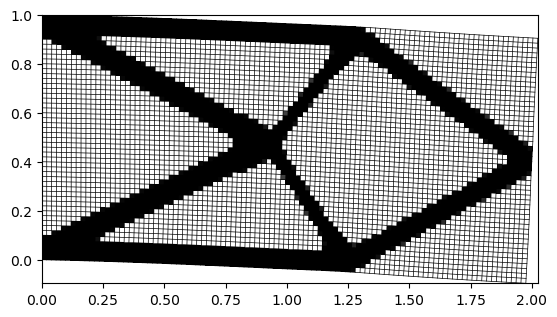

In [17]:
plot_deformation(sens, x_proj, sens.d, scale=0.001)

In [ ]:
import numpy as np
from sens_elastic import MBB as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.5 # 設計領域の体積比率
sens = Sens() # 弾性場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta = 0.5 # しきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
fil = Projection(sens.n1, sens.n2, r, eta, beta0) # ヘビサイドプロジェクション
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x) # 密度フィルタ・ヘビサイドプロジェクション後の設計変数
    m_nd = fil.grayscale_indicator(x_proj) # グレースケール指標
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.03e+03, g = 0.00e+00, norm_inf_x = 5.0e-02, m_nd = 100.00
1 iters, f = 8.26e+02, g = -4.73e-03, norm_inf_x = 5.0e-02, m_nd = 99.00
2 iters, f = 6.86e+02, g = -4.17e-03, norm_inf_x = 5.0e-02, m_nd = 96.42
3 iters, f = 5.91e+02, g = -2.79e-03, norm_inf_x = 5.0e-02, m_nd = 93.41
4 iters, f = 5.25e+02, g = -2.27e-03, norm_inf_x = 5.0e-02, m_nd = 90.25
5 iters, f = 4.72e+02, g = -2.04e-03, norm_inf_x = 5.0e-02, m_nd = 87.02
6 iters, f = 4.29e+02, g = -1.78e-03, norm_inf_x = 5.0e-02, m_nd = 83.56
7 iters, f = 3.92e+02, g = -1.54e-03, norm_inf_x = 5.0e-02, m_nd = 79.80
8 iters, f = 3.60e+02, g = -1.35e-03, norm_inf_x = 5.0e-02, m_nd = 75.80
9 iters, f = 3.32e+02, g = -1.24e-03, norm_inf_x = 5.0e-02, m_nd = 71.40
10 iters, f = 3.07e+02, g = -1.11e-03, norm_inf_x = 5.0e-02, m_nd = 66.83
11 iters, f = 2.96e+02, g = -8.52e-04, norm_inf_x = 5.0e-02, m_nd = 65.49
12 iters, f = 2.87e+02, g = -7.40e-04, norm_inf_x = 5.0e-02, m_nd = 63.43
13 iters, f = 2.79e+02, g = -7.35e-04, norm_inf_

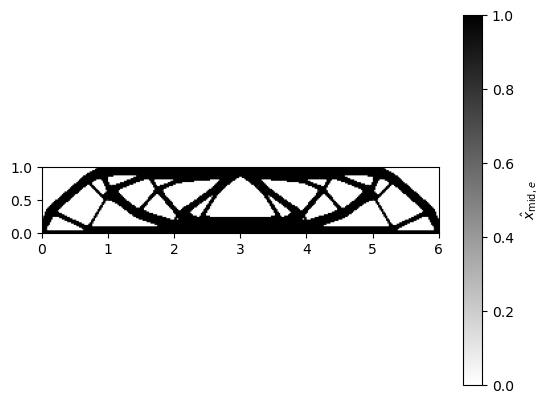

In [5]:
import matplotlib.pyplot as plt
x_proj_full = np.hstack([np.flip(x_proj.reshape((sens.n2, sens.n1)), axis=1), x_proj.reshape((sens.n2, sens.n1))])
plt.imshow(x_proj_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[0, 2*sens.L1, 0, sens.L2])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

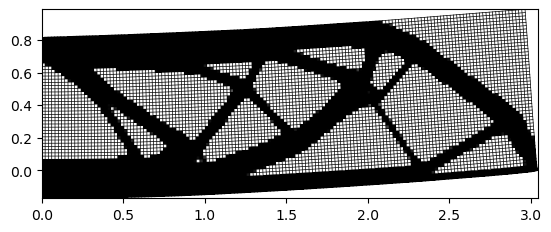

In [ ]:
plot_deformation(sens, x_proj, sens.d, scale=0.001)

In [ ]:
import numpy as np
from sens_elastic_compmech import Invertor as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 弾性場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta = 0.5 # しきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
fil = Projection(sens.n1, sens.n2, r, eta, beta0) # ヘビサイドプロジェクション
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x) # 密度フィルタ・ヘビサイドプロジェクション後の設計変数
    m_nd = fil.grayscale_indicator(x_proj) # グレースケール指標
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 8.90e-02, g = -1.36e-02, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 3.28e-02, g = -2.54e-02, norm_inf_x = 5.0e-02, m_nd = 79.04
2 iters, f = 7.76e-03, g = -2.86e-02, norm_inf_x = 5.0e-02, m_nd = 76.75
3 iters, f = 9.69e-04, g = -3.00e-02, norm_inf_x = 5.0e-02, m_nd = 74.48
4 iters, f = 2.67e-05, g = -3.43e-02, norm_inf_x = 4.9e-02, m_nd = 72.21
5 iters, f = -1.29e-06, g = -3.65e-02, norm_inf_x = 4.7e-02, m_nd = 71.33
6 iters, f = -4.05e-05, g = -3.65e-02, norm_inf_x = 5.0e-02, m_nd = 71.31
7 iters, f = -9.83e-04, g = -3.87e-02, norm_inf_x = 5.0e-02, m_nd = 70.45
8 iters, f = -8.64e-03, g = -4.32e-02, norm_inf_x = 5.0e-02, m_nd = 68.11
9 iters, f = -2.41e-02, g = -4.24e-02, norm_inf_x = 5.0e-02, m_nd = 66.30
10 iters, f = -4.86e-02, g = -3.14e-02, norm_inf_x = 5.0e-02, m_nd = 66.21
11 iters, f = -8.30e-02, g = -1.85e-02, norm_inf_x = 5.0e-02, m_nd = 65.03
12 iters, f = -1.25e-01, g = -1.20e-03, norm_inf_x = 5.0e-02, m_nd = 64.48
13 iters, f = -1.72e-01, g = -1.05e-03, 

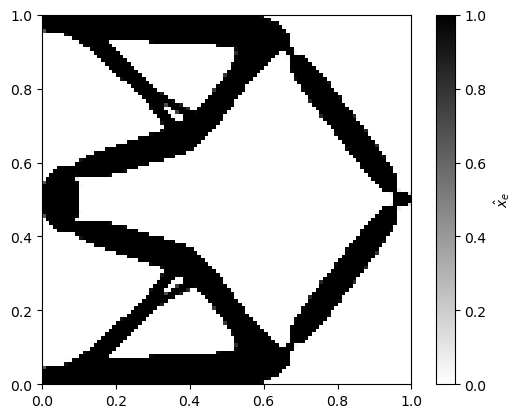

In [8]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_proj_reshaped = x_proj.reshape(sens.n2, sens.n1)
x_proj_full = np.vstack([x_proj_reshaped, np.flip(x_proj_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_proj_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

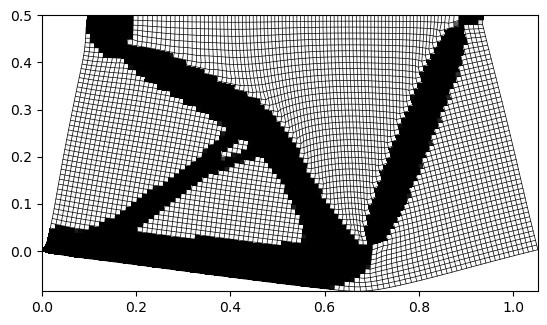

In [9]:
plot_deformation(sens, x_proj, sens.d, scale=0.1)

In [2]:
import numpy as np
from sens_elastic_compmech import Invertor as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 弾性場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g, gradg_proj = volume_constraint(x_mid)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.28e-01, g = -1.36e-02, norm_inf_x = 6.4e-02, m_nd = 81.76
1 iters, f = 5.23e-02, g = -2.43e-02, norm_inf_x = 6.6e-02, m_nd = 79.18
2 iters, f = 1.41e-02, g = -2.70e-02, norm_inf_x = 6.1e-02, m_nd = 76.86
3 iters, f = 2.08e-03, g = -2.77e-02, norm_inf_x = 5.4e-02, m_nd = 74.45
4 iters, f = 7.53e-05, g = -3.20e-02, norm_inf_x = 8.6e-02, m_nd = 71.79
5 iters, f = -1.33e-06, g = -3.59e-02, norm_inf_x = 6.1e-02, m_nd = 70.25
6 iters, f = -3.49e-05, g = -3.58e-02, norm_inf_x = 9.4e-02, m_nd = 70.27
7 iters, f = -5.56e-04, g = -3.69e-02, norm_inf_x = 1.0e-01, m_nd = 69.86
8 iters, f = -4.40e-03, g = -4.12e-02, norm_inf_x = 1.2e-01, m_nd = 68.07
9 iters, f = -1.29e-02, g = -4.10e-02, norm_inf_x = 1.5e-01, m_nd = 66.92
10 iters, f = -2.77e-02, g = -3.14e-02, norm_inf_x = 1.7e-01, m_nd = 66.94
11 iters, f = -5.05e-02, g = -1.76e-02, norm_inf_x = 1.7e-01, m_nd = 66.63
12 iters, f = -8.17e-02, g = -1.23e-03, norm_inf_x = 1.6e-01, m_nd = 66.31
13 iters, f = -1.20e-01, g = -1.19e-03, 

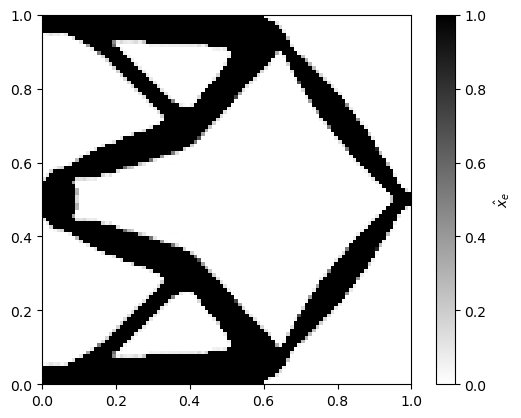

In [3]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_mid_reshaped = x_mid.reshape(sens.n2, sens.n1)
x_mid_full = np.vstack([x_mid_reshaped, np.flip(x_mid_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_mid_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

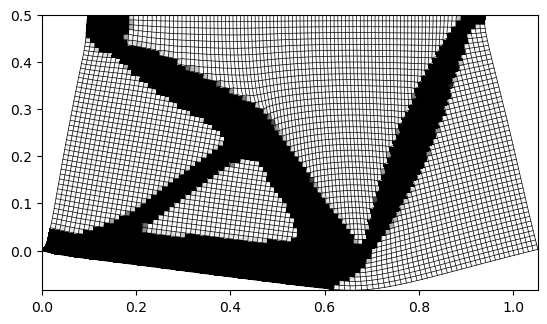

In [6]:
plot_deformation(sens, x_mid, sens.d, scale=0.1)

In [ ]:
import numpy as np
from sens_elastic_compmech import Gripper as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 弾性場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g, gradg_proj = volume_constraint(x_mid)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.18e-02, g = -2.44e-02, norm_inf_x = 7.5e-01, m_nd = 71.54
1 iters, f = 4.45e-04, g = -2.60e-02, norm_inf_x = 7.6e-01, m_nd = 70.53
2 iters, f = -3.84e-03, g = -2.36e-02, norm_inf_x = 7.1e-01, m_nd = 69.54
3 iters, f = -1.41e-02, g = -1.65e-02, norm_inf_x = 7.0e-01, m_nd = 69.25
4 iters, f = -3.39e-02, g = -7.86e-03, norm_inf_x = 7.4e-01, m_nd = 68.18
5 iters, f = -6.04e-02, g = 7.81e-04, norm_inf_x = 7.8e-01, m_nd = 66.20
6 iters, f = -8.88e-02, g = 2.76e-03, norm_inf_x = 8.3e-01, m_nd = 62.71
7 iters, f = -1.17e-01, g = 3.51e-03, norm_inf_x = 8.8e-01, m_nd = 59.92
8 iters, f = -1.46e-01, g = 3.84e-03, norm_inf_x = 9.3e-01, m_nd = 56.92
9 iters, f = -1.75e-01, g = 4.01e-03, norm_inf_x = 9.8e-01, m_nd = 53.55
10 iters, f = -2.05e-01, g = 4.08e-03, norm_inf_x = 1.0e+00, m_nd = 49.85
11 iters, f = -2.31e-01, g = 1.26e-03, norm_inf_x = 1.0e+00, m_nd = 46.06
12 iters, f = -2.57e-01, g = -7.01e-04, norm_inf_x = 1.0e+00, m_nd = 42.48
13 iters, f = -2.84e-01, g = -6.45e-04, norm

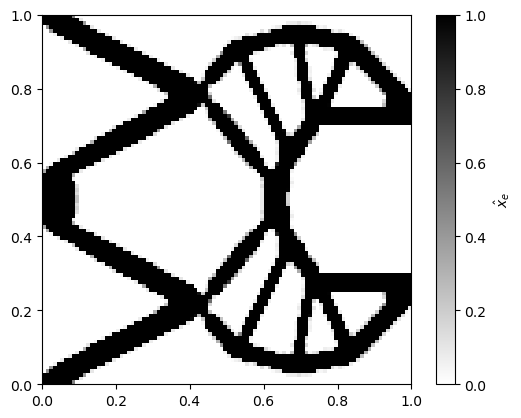

In [4]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_mid_reshaped = x_mid.reshape(sens.n2, sens.n1)
x_mid_full = np.vstack([x_mid_reshaped, np.flip(x_mid_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_mid_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

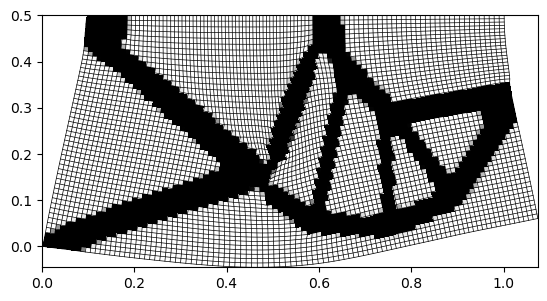

In [8]:
plot_deformation(sens, x_mid, sens.d, scale=0.1)